# Data Source Scaling Comparison

Scaling curves for six training data sources — QF-only, LI-only, their
deduplicated Union, and three Unfiltered orderings (shuffled, oldest-first,
newest-first) — all trained with the same schedule and model capacities.
States subsampled with `drop_prob=0.9`; variance across seeds comes from
different random state drops.

Schedule: 2K -> 200K games, 5 seeds per scale point.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Load all six result sets (base scaling: 5 seeds, no sym-aug)
sources = {}
for name, path in [
    ('Union', 'combined_union_scaling_results.json'),
    ('QF-only', 'qf_only_scaling_results.json'),
    ('LI-only', 'li_only_scaling_results.json'),
    ('Unfiltered', 'unfiltered_scaling_results.json'),
    ('Unf-Oldest', 'unfiltered_oldest_scaling_results.json'),
    ('Unf-Newest', 'unfiltered_newest_scaling_results.json'),
]:
    with open(path) as f:
        d = json.load(f)
    grp = defaultdict(list)
    for run in d['runs']:
        key = (run['max_games'], run['num_leaves'], run['num_trees'])
        grp[key].append(run)
    sources[name] = grp

# Load sym-aug results (10 seeds, 200K games, 100L/100T)
# Keyed as (400000, 100, 100) to place them at "400K" on x-axis
symaug_files = {
    'Union': 'union_200k_symaug_results.json',
    'QF-only': 'qf_200k_symaug_results.json',
    'LI-only': 'li_200k_symaug_results.json',
    'Unfiltered': 'unfiltered_200k_symaug_results.json',
    'Unf-Oldest': 'unfiltered_oldest_200k_symaug_results.json',
    'Unf-Newest': 'unfiltered_newest_200k_symaug_results.json',
}
for name, path in symaug_files.items():
    with open(path) as f:
        d = json.load(f)
    for run in d['runs']:
        key = (400000, run['num_leaves'], run['num_trees'])
        sources[name][key].append(run)

# Use union's keys as reference
ref_keys = sorted(sources['Union'].keys())
ref_game_counts = [k[0] for k in ref_keys]
drop_prob = 0.9
n_seeds = max(len(sources['Union'][k]) for k in ref_keys)
source_names = list(sources.keys())

print(f'Loaded {len(sources)} sources, {len(ref_keys)} scale points, '
      f'drop_prob={drop_prob}')
print(f'Scale points: {ref_game_counts}')
print(f'Last point (400K) = 200K games + sym-aug, 10 seeds')

Loaded 6 sources, 8 scale points, drop_prob=0.9
Scale points: [2000, 5000, 10000, 20000, 50000, 100000, 200000, 400000]
Last point (400K) = 200K games + sym-aug, 10 seeds


In [2]:
def fmt(vals):
    return f'{np.mean(vals):.4f} +/- {np.std(vals):.4f}'

show_games = {2000, 20000, 200000, 400000}

print(f'{"Source":>14} {"Games":>8}  {"Log Loss":>18}  {"Accuracy":>18}  '
      f'{"AUC":>18}  {"Egg":>18}  {"SymDev":>18}')
print('-' * 130)

for name in source_names:
    grp = sources[name]
    for key in ref_keys:
        mg = key[0]
        if mg not in show_games:
            continue
        runs = grp.get(key, [])
        if not runs:
            continue
        loss = [r['metrics']['standard']['log_loss'] for r in runs]
        acc = [r['metrics']['standard']['accuracy'] for r in runs]
        auc = [r['metrics']['standard']['auc_roc'] for r in runs]
        egg = [r['metrics']['kq']['egg_inversion_rate'] for r in runs]
        sym = [r['metrics']['kq']['symmetry_deviation'] for r in runs]
        label = f'{mg//1000}K+sym' if mg == 400000 else str(mg)
        print(f'{name:>14} {label:>8}  {fmt(loss)}  {fmt(acc)}  '
              f'{fmt(auc)}  {fmt(egg)}  {fmt(sym)}')
    print()

        Source    Games            Log Loss            Accuracy                 AUC                 Egg              SymDev
----------------------------------------------------------------------------------------------------------------------------------
         Union     2000  0.5856 +/- 0.0007  0.6809 +/- 0.0018  0.7569 +/- 0.0012  0.0578 +/- 0.0110  0.0586 +/- 0.0016
         Union    20000  0.5714 +/- 0.0003  0.6875 +/- 0.0005  0.7656 +/- 0.0003  0.0240 +/- 0.0027  0.0383 +/- 0.0011
         Union   200000  0.5689 +/- 0.0003  0.6892 +/- 0.0005  0.7675 +/- 0.0003  0.0142 +/- 0.0010  0.0290 +/- 0.0002
         Union 400K+sym  0.5676 +/- 0.0003  0.6905 +/- 0.0005  0.7687 +/- 0.0004  0.0088 +/- 0.0012  0.0126 +/- 0.0002

       QF-only     2000  0.5897 +/- 0.0012  0.6805 +/- 0.0010  0.7551 +/- 0.0014  0.0511 +/- 0.0093  0.0564 +/- 0.0035
       QF-only    20000  0.5714 +/- 0.0009  0.6877 +/- 0.0012  0.7659 +/- 0.0011  0.0230 +/- 0.0027  0.0388 +/- 0.0010
       QF-only   200000  0.567

Saved source_comparison_early.png


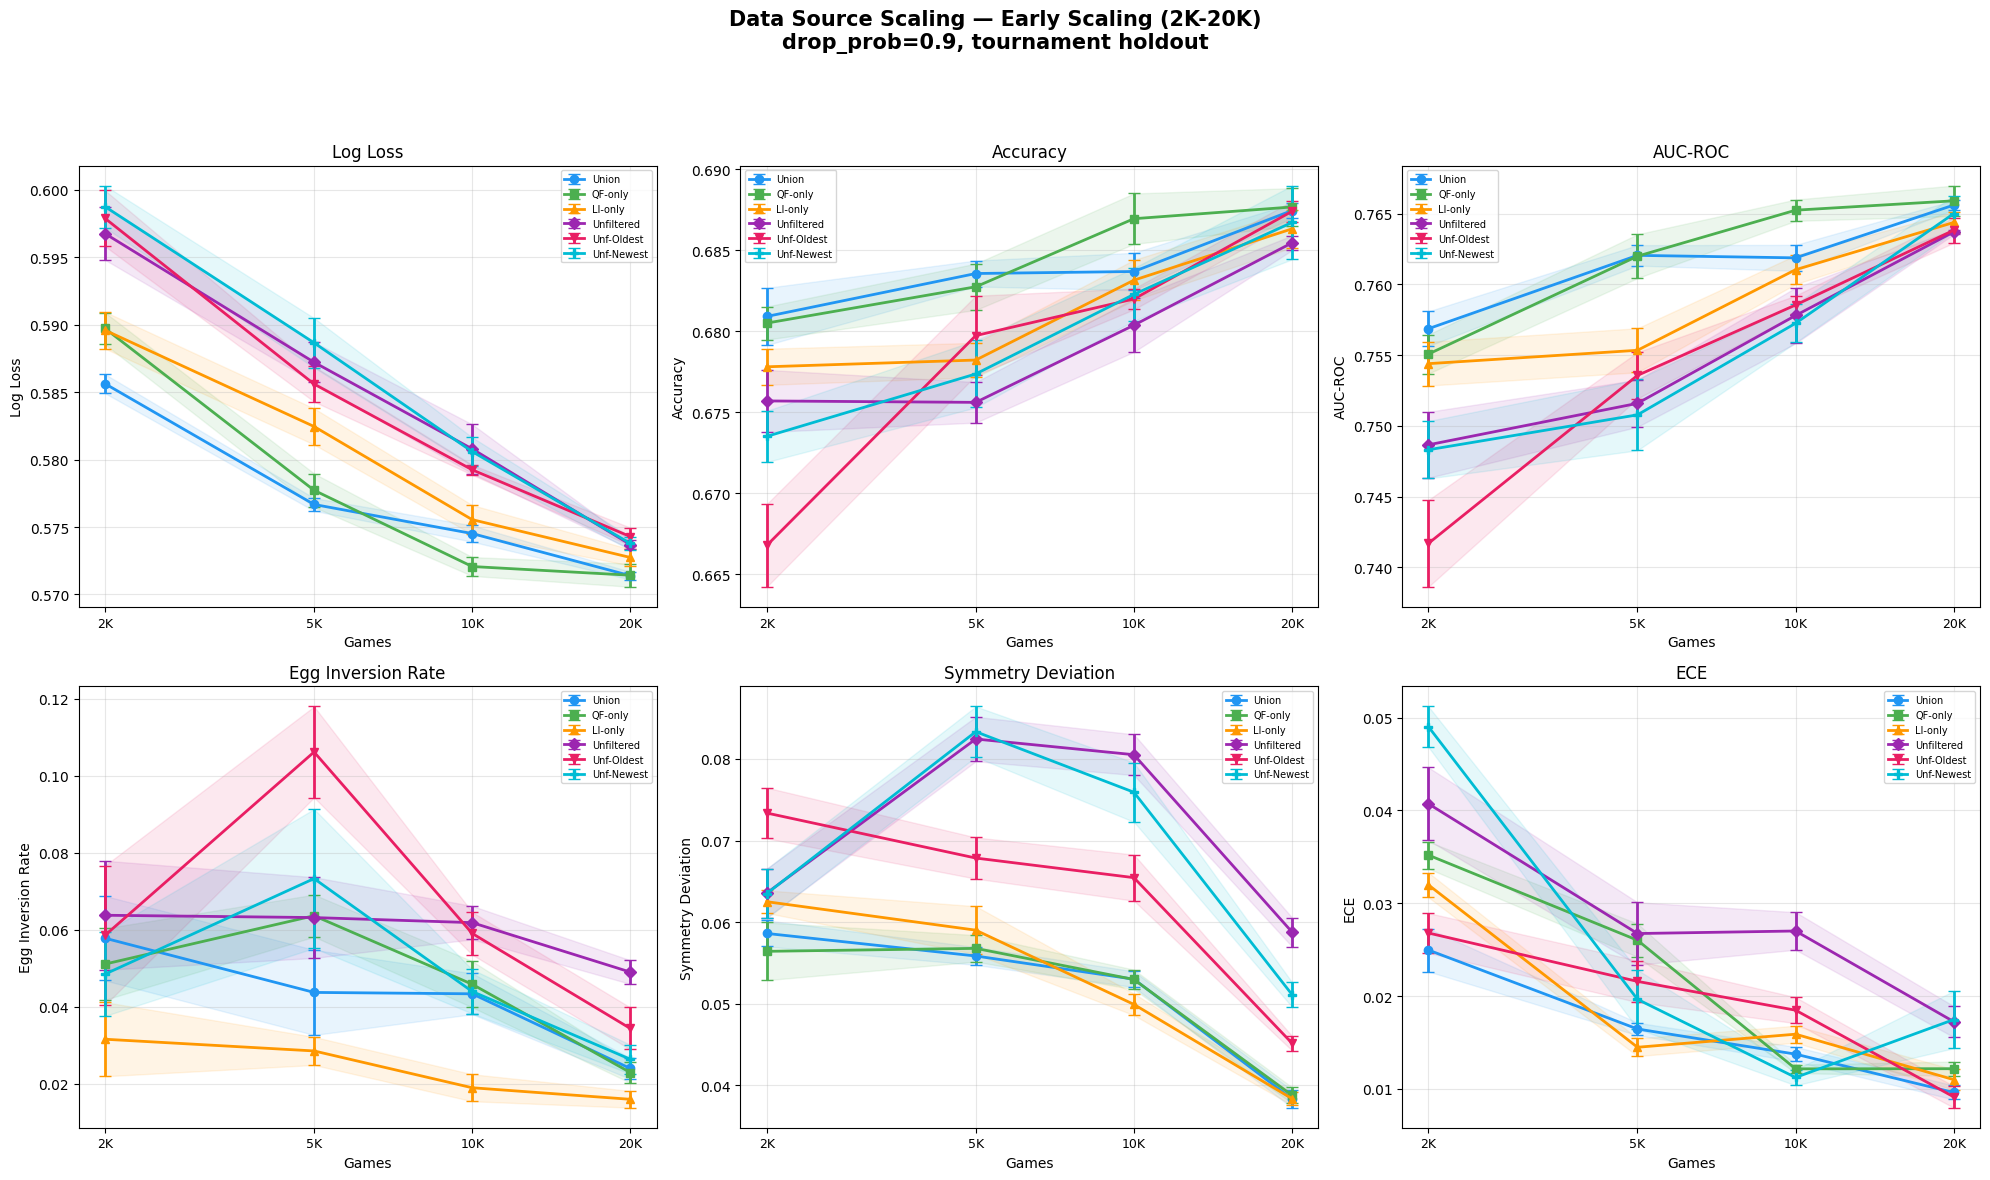

Saved source_comparison_late.png


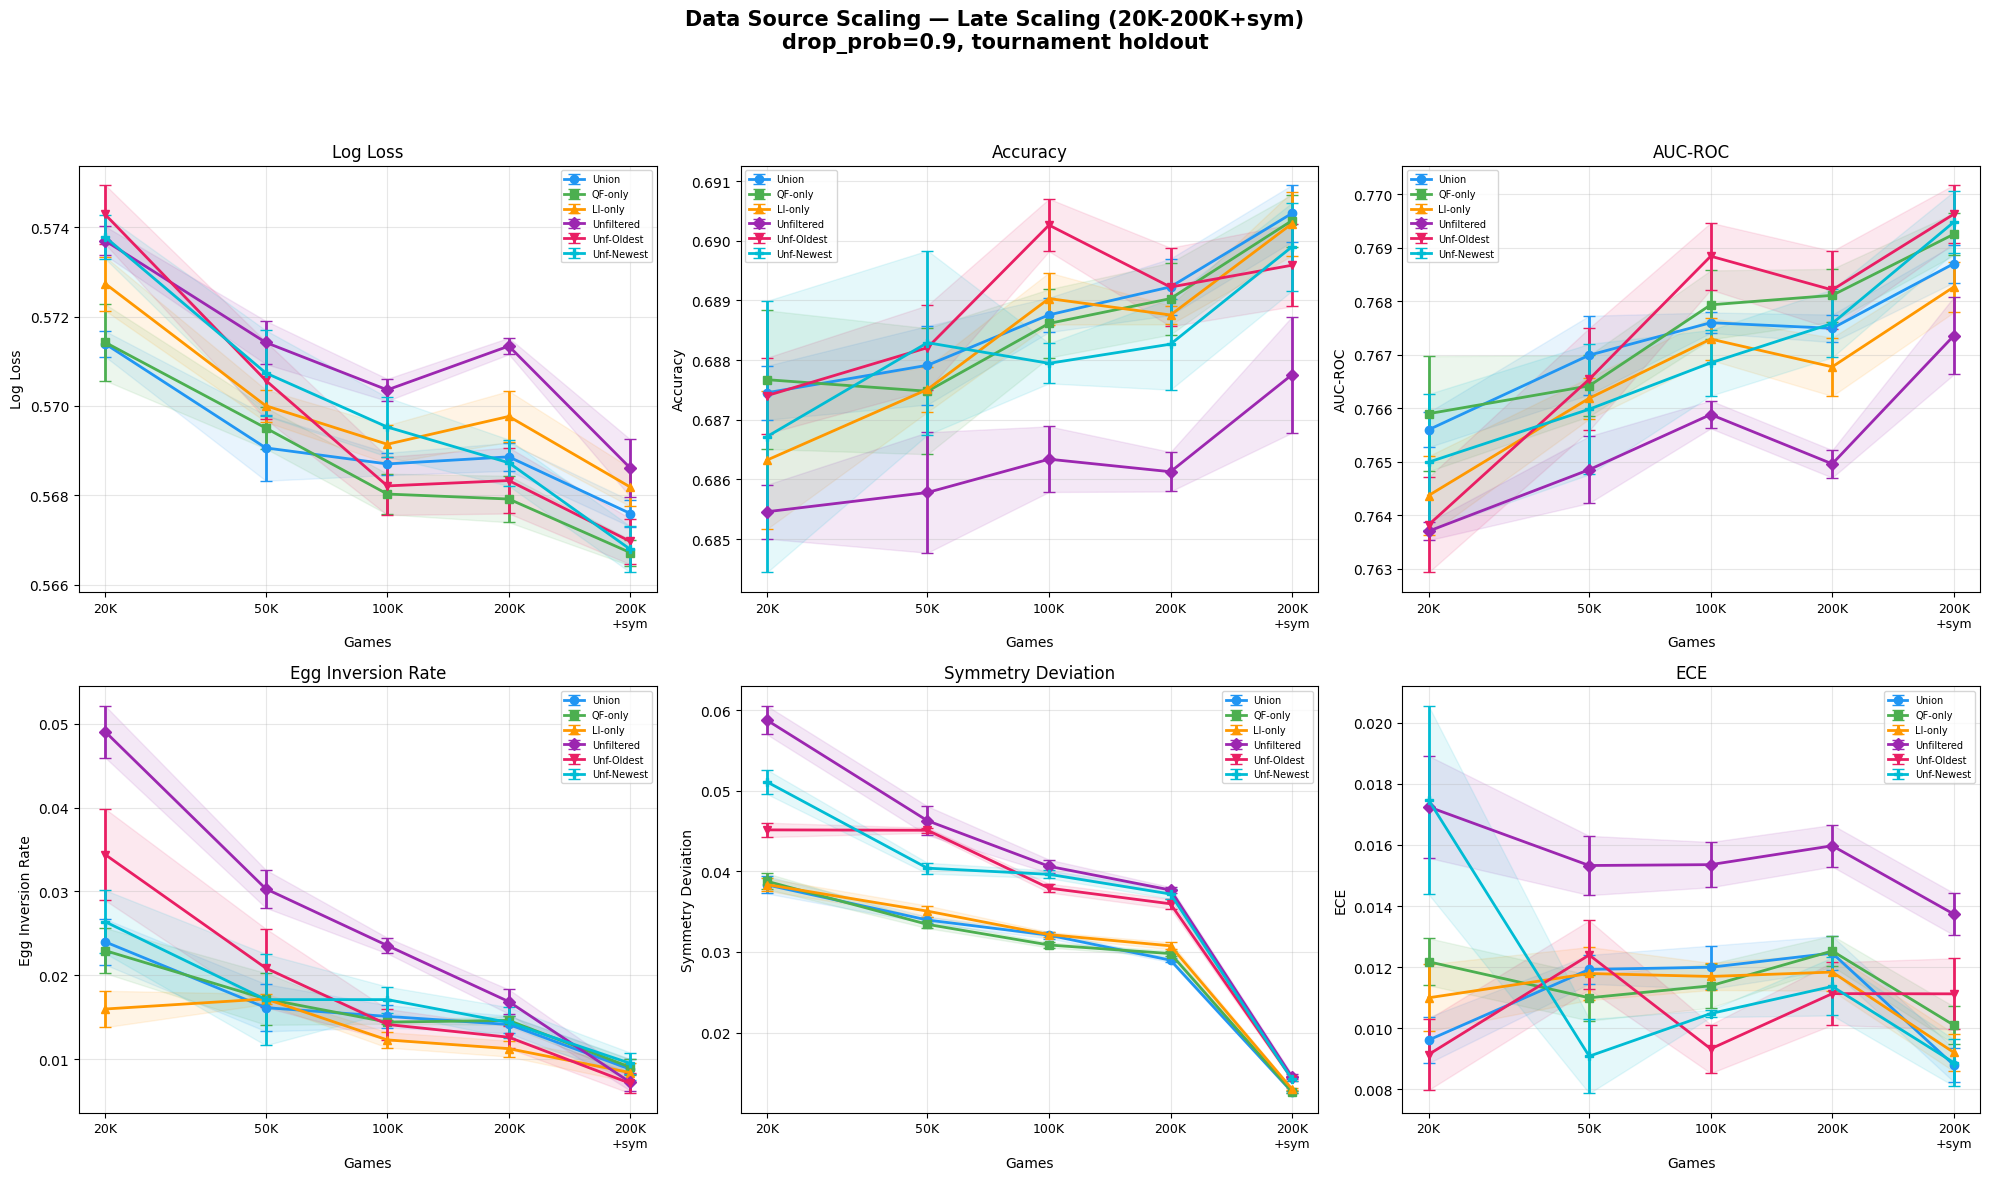

In [3]:
colors = {
    'Union': '#2196F3', 'QF-only': '#4CAF50', 'LI-only': '#FF9800',
    'Unfiltered': '#9C27B0', 'Unf-Oldest': '#E91E63', 'Unf-Newest': '#00BCD4',
}
markers = {
    'Union': 'o', 'QF-only': 's', 'LI-only': '^',
    'Unfiltered': 'D', 'Unf-Oldest': 'v', 'Unf-Newest': 'P',
}

compare_metrics = [
    ('standard', 'log_loss', 'Log Loss'),
    ('standard', 'accuracy', 'Accuracy'),
    ('standard', 'auc_roc', 'AUC-ROC'),
    ('kq', 'egg_inversion_rate', 'Egg Inversion Rate'),
    ('kq', 'symmetry_deviation', 'Symmetry Deviation'),
    ('calibration', 'ece', 'ECE'),
]

def get_stats(name, keys, suite, metric_key):
    grp = sources[name]
    means, stds = [], []
    for key in keys:
        runs = grp.get(key, [])
        vals = [r['metrics'][suite][metric_key] for r in runs]
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    return np.array(means), np.array(stds)

def tick_label(mg):
    if mg == 400000:
        return '200K\n+sym'
    return f'{mg//1000}K'

# Split: early = 2K-20K, late = 20K-400K (20K appears in both)
early_keys = ref_keys[:4]   # 2K, 5K, 10K, 20K
late_keys  = ref_keys[3:]   # 20K, 50K, 100K, 200K, 400K(sym-aug)
early_gc = [k[0] for k in early_keys]
late_gc  = [k[0] for k in late_keys]

for phase, keys, gc, title_suffix in [
    ('early', early_keys, early_gc, 'Early Scaling (2K-20K)'),
    ('late',  late_keys,  late_gc,  'Late Scaling (20K-200K+sym)'),
]:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()

    for ax, (suite, metric_key, label) in zip(axes, compare_metrics):
        for name in source_names:
            means, stds = get_stats(name, keys, suite, metric_key)
            ax.errorbar(gc, means, yerr=stds,
                        marker=markers[name], capsize=4, linewidth=2,
                        color=colors[name], label=name)
            ax.fill_between(gc, means - stds, means + stds,
                            alpha=0.1, color=colors[name])

        ax.set_xlabel('Games')
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.set_xscale('log', base=2)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(gc)
        ax.set_xticklabels([tick_label(mg) for mg in gc], fontsize=9)

    fig.suptitle(f'Data Source Scaling — {title_suffix}\n'
                 f'drop_prob={drop_prob}, tournament holdout',
                 fontsize=15, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(f'source_comparison_{phase}.png', dpi=200, bbox_inches='tight')
    print(f'Saved source_comparison_{phase}.png')
    plt.show()